# E-Commerce Sales & Customer Behavior Analysis
Author: Ronachel Marie  
Project: Brazilian E-commerce Sales Analysis  
Tools: Python, Pandas, Seaborn, Plotly  

## Executive Summary

This project analyzes transactional data from the Olist Brazilian
e-commerce platform to uncover insights into sales performance,
customer behavior, and geographic demand patterns.

Key findings from the analysis include:

• Sales demonstrate clear seasonal patterns, with significant growth
toward the end of the year.

• Revenue is concentrated in a limited number of product categories.

• Customer demand is geographically clustered in major Brazilian
states and metropolitan areas.

• Customer retention declines sharply after the first purchase,
suggesting opportunities for improved engagement strategies.

These insights provide actionable opportunities for improving marketing
strategies, inventory planning, and logistics optimization.

## Business Problem

Understanding customer purchasing behavior and sales trends is critical for
e-commerce platforms to optimize marketing strategies, inventory management,
and logistics.

This project analyzes transactional data from the Olist Brazilian e-commerce
platform to answer the following business questions:

• How have sales evolved over time?
• Which product categories generate the most revenue?
• Where are customers geographically located?
• Are there seasonal purchasing patterns?

The goal of this analysis is to extract actionable insights that could help
e-commerce businesses improve revenue, customer engagement, and operational
efficiency.

## Data Processing Pipeline

The analysis follows a structured data pipeline:

1. Load raw datasets
2. Perform data cleaning and handle missing values
3. Merge relational tables
4. Engineer new analytical features
5. Conduct exploratory analysis and visualizations
6. Generate business insights and recommendations

This workflow ensures the analysis remains reproducible and transparent.

## Dataset Overview

This dataset contains real transactional data from the Brazilian e-commerce
platform Olist. The analysis uses four relational tables:

• orders — contains order timestamps and order status

• order_items — contains product prices and order details

• products — contains product categories and attributes

• customers — contains customer geographic information


These tables were merged to construct a unified dataset for sales analysis.

In [41]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [42]:
# load datasets
orders = pd.read_csv(
    "dataset/olist_orders_dataset.csv",
    parse_dates=["order_purchase_timestamp",
                 "order_approved_at", "order_delivered_carrier_date",
                 "order_delivered_customer_date",
                 "order_estimated_delivery_date"]
)

order_items = pd.read_csv("dataset/olist_order_items_dataset.csv")
products = pd.read_csv("dataset/olist_products_dataset.csv")
customers = pd.read_csv("dataset/olist_customers_dataset.csv")

print("Loaded successfully!")

Loaded successfully!


## Data Quality Assessment

Before performing the analysis, the dataset was examined to evaluate
data completeness, consistency, and potential anomalies.

The following checks were conducted:

• Missing value analysis across all tables

• Duplicate record detection

• Data type verification

• Inspection of key relational fields used for table joins


Understanding the quality of the dataset helps ensure that downstream
analysis and insights are reliable.

In [57]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [58]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [59]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [60]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [61]:
orders.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99281,97658,96476,99441
mean,2017-12-31 08:43:12.776581,2017-12-31 18:35:24.098800,2018-01-04 21:49:48.138278,2018-01-14 12:09:19.035542,2018-01-24 03:08:37.730111
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.250000,2017-09-25 22:07:22.250000,2017-10-03 00:00:00
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.250000,2018-05-25 00:00:00
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


In [62]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [63]:
orders['order_status'].unique()

<StringArray>
[  'delivered',    'invoiced',     'shipped',  'processing', 'unavailable',
    'canceled',     'created',    'approved']
Length: 8, dtype: str

In [64]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [65]:
order_items['order_item_id'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21])

In [66]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [67]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


### Check for missing values

In [68]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

This implies that some orders may be canceled, not shipped yet, still processing. So we should **NOT** fill these values with fake data.
Instead we do keep them as NaN to preserve the real order lifecycle.

In [69]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [70]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [71]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

### Check for duplicates

In [72]:
orders.duplicated().sum()

np.int64(0)

In [73]:
order_items.duplicated().sum()

np.int64(0)

In [74]:
products.duplicated().sum()

np.int64(0)

In [75]:
customers.duplicated().sum()

np.int64(0)

## Data Cleaning

In [76]:
# ensure string columns are string type
## from order_items
order_items['order_item_id'] = order_items['order_item_id'].astype(str)
## from customers
customers['customer_zip_code_prefix'] = customers['customer_zip_code_prefix'].astype(str)

In [77]:
order_items.dtypes

order_id                   str
order_item_id              str
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

In [78]:
customers.dtypes

customer_id                 str
customer_unique_id          str
customer_zip_code_prefix    str
customer_city               str
customer_state              str
dtype: object

In [84]:
# fill with unkown
products["product_category_name"] = products["product_category_name"].fillna("Unknown")

In [95]:
# fill missing values with median to avoid outlier influence
products["product_name_lenght"] = products["product_name_lenght"].fillna(
    products["product_name_lenght"].median()
)
products["product_description_lenght"] = products["product_description_lenght"].fillna(
    products["product_description_lenght"].median()
)
products["product_photos_qty"] = products["product_photos_qty"].fillna(
    products["product_photos_qty"].median()
)
products["product_weight_g"] = products["product_weight_g"].fillna(
    products["product_weight_g"].median()
)
products["product_length_cm"] = products["product_length_cm"].fillna(
    products["product_length_cm"].median()
)
products["product_height_cm"] = products["product_height_cm"].fillna(
    products["product_height_cm"].median()
)
products["product_width_cm"] = products["product_width_cm"].fillna(
    products["product_width_cm"].median()
)

In [96]:
products.isnull().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

Missing product category values were filled with "Unknown" to retain the rows.

Numeric product attributes were filled using the median to avoid distortion
from outliers.

### Merge Tables

In [10]:
sales = orders.merge(order_items, on="order_id")
sales = sales.merge(products, on="product_id")
sales = sales.merge(customers, on="customer_id")

In [11]:
sales.shape

(112650, 26)

In [12]:
sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,178.0,1.0,400.0,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,232.0,1.0,420.0,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,468.0,3.0,450.0,30.0,10.0,20.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,316.0,4.0,250.0,51.0,15.0,15.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


## Feature Engineering

Several derived features were created to enhance the analytical
capabilities of the dataset.

Time-based variables such as order_month and order_year were extracted
from the purchase timestamp to enable time-series analysis and seasonal
trend identification.

Additionally, total_price was calculated by combining product price and
freight value to represent the full order cost from the customer's
perspective.

These engineered features enable deeper insights into purchasing
patterns and revenue dynamics.

In [16]:
# extract time features
sales["order_year"] = sales["order_purchase_timestamp"].dt.year
sales["order_month"] = sales["order_purchase_timestamp"].dt.month
sales["order_day"] = sales["order_purchase_timestamp"].dt.day
sales["order_month_year"] = sales["order_purchase_timestamp"].dt.to_period("M")

# calculate total order value
sales["total_price"] = sales["price"] + sales["freight_value"]

In [115]:
monthly_sales = sales.groupby('order_month')['price'].sum()
monthly_sales

order_month
1     1070343.23
2     1091481.73
3     1357557.74
4     1356574.98
5     1502588.82
6     1298162.91
7     1393538.70
8     1428658.01
9      624814.05
10     713727.09
11    1010271.37
12     743925.07
Name: price, dtype: float64

## Exploratory Data Analysis

### Order Value Distribution

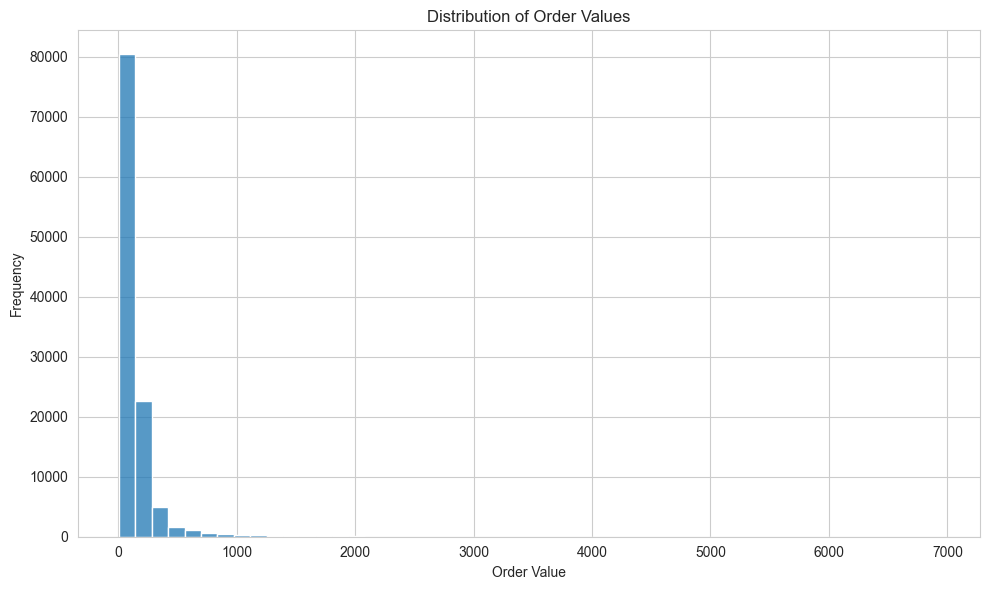

In [35]:
plt.figure(figsize=(10,6))

sns.histplot(sales["total_price"], bins=50)

plt.title("Distribution of Order Values")
plt.xlabel("Order Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Insight

The distribution of order values is highly right-skewed, meaning that
most transactions involve relatively small purchases while a smaller
number of orders account for higher transaction values.

This pattern is common in e-commerce platforms and suggests that a small
subset of customers or product categories contributes disproportionately
to overall revenue.

## Key Visualizations

### Monthly Revenue Trend

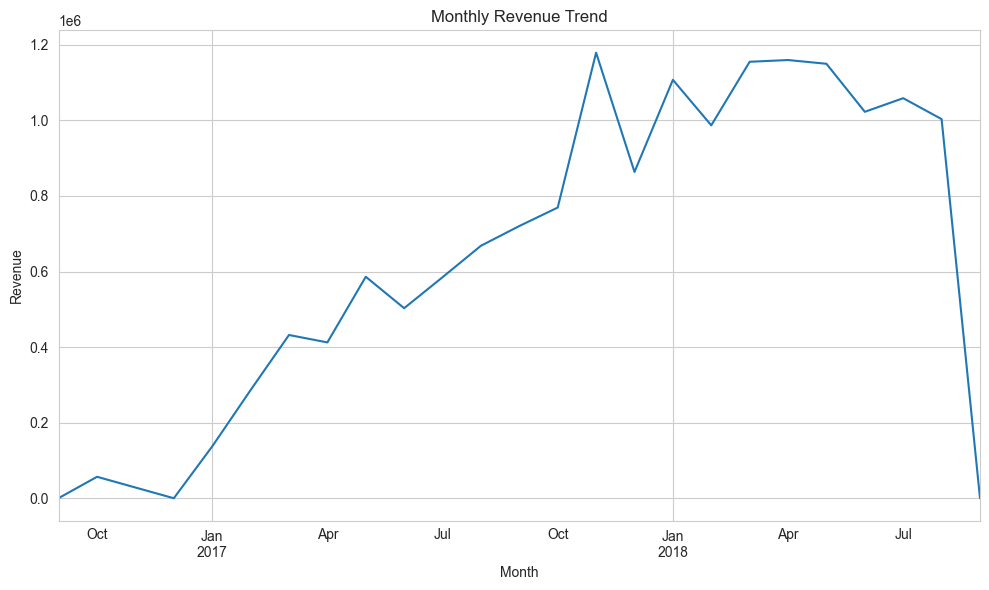

In [46]:
# monthly revenue trend
monthly_sales = sales.groupby("order_month_year")["total_price"].sum()

monthly_sales.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("visualizations/sales_trend.png", dpi=300, bbox_inches="tight")
plt.show()

#### Insight

The monthly revenue trend reveals a clear upward trajectory in sales
over time, indicating growing platform adoption.

Several peaks appear toward the end of the year, suggesting strong
seasonal purchasing behavior. This pattern likely reflects increased
consumer spending during holiday periods and promotional events.

Understanding these seasonal patterns can help e-commerce businesses
optimize marketing campaigns, inventory planning, and logistics
capacity during high-demand periods.

### Top Product Categories

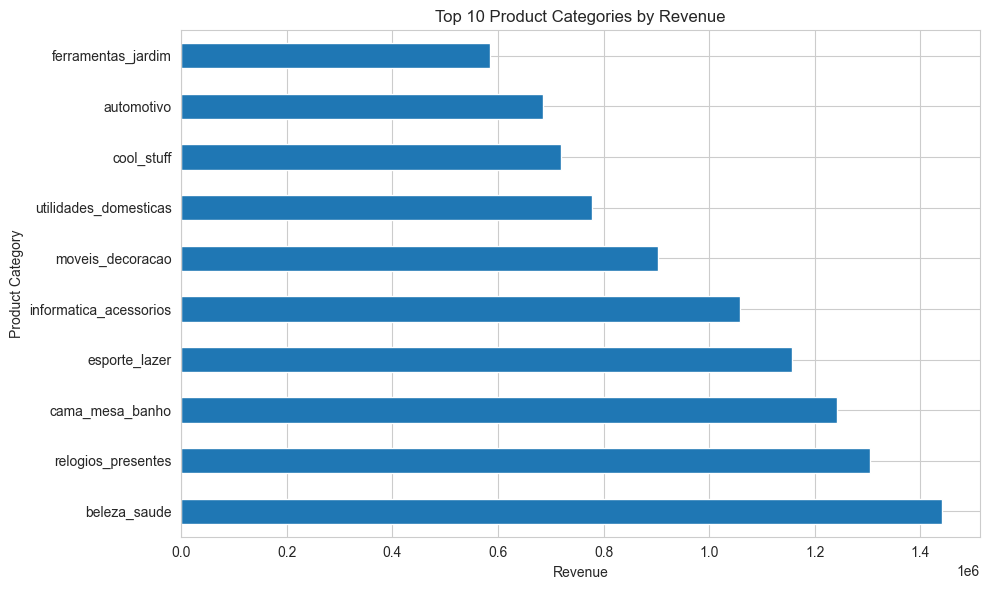

In [48]:
# top product categories
top_categories = sales.groupby("product_category_name")["total_price"].sum() \
    .sort_values(ascending=False).head(10)

top_categories.plot(kind="barh")

plt.title("Top 10 Product Categories by Revenue")
plt.ylabel("Product Category")
plt.xlabel("Revenue")

plt.tight_layout()
plt.savefig("visualizations/top_categories.png", dpi=300, bbox_inches="tight")
plt.show()

#### Insight

Revenue distribution across product categories shows that a small number
of categories account for a significant portion of total sales.

This indicates that the platform’s revenue is concentrated within a few
high-demand product segments. Businesses could leverage this insight by
prioritizing inventory management and promotional campaigns for these
high-performing categories.

Additionally, identifying underperforming categories could help guide
strategic decisions such as product assortment expansion or targeted
marketing initiatives.

### Sales Heatmap
Demonstate seasonality patterns

In [37]:
sales_heatmap = sales.pivot_table(
    values="price",
    index=sales["order_purchase_timestamp"].dt.month,
    columns=sales["order_purchase_timestamp"].dt.year,
    aggfunc="sum"
)

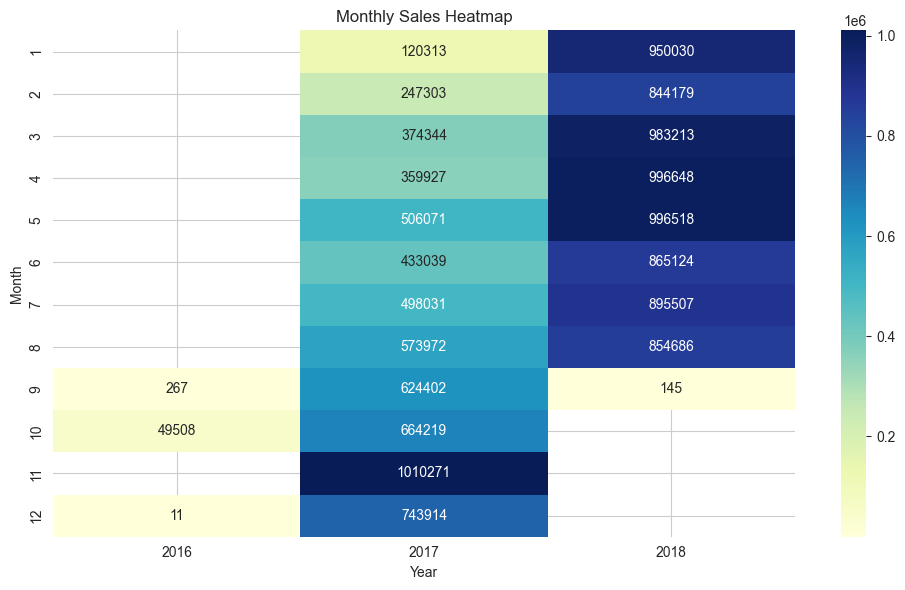

In [49]:
plt.figure(figsize=(10,6))

sns.heatmap(sales_heatmap, cmap="YlGnBu", annot=True, fmt=".0f")

plt.title("Monthly Sales Heatmap")
plt.xlabel("Year")
plt.ylabel("Month")

plt.tight_layout()
plt.savefig("visualizations/sales_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

#### Insight

The heatmap highlights strong seasonal sales patterns across the
observed years. Revenue tends to increase significantly during the final
quarter of the year, particularly in November and December.

These months likely correspond with major shopping periods such as
holiday sales and promotional events. Recognizing these seasonal peaks
is essential for planning marketing campaigns, inventory stocking, and
logistics operations during periods of high demand.

## Geographic Sales Analysis

Understanding the geographic distribution of customers helps identify regions
with the highest demand. This insight can guide logistics expansion,
regional marketing strategies, and warehouse placement.

The map below visualizes total revenue generated by each Brazilian state.

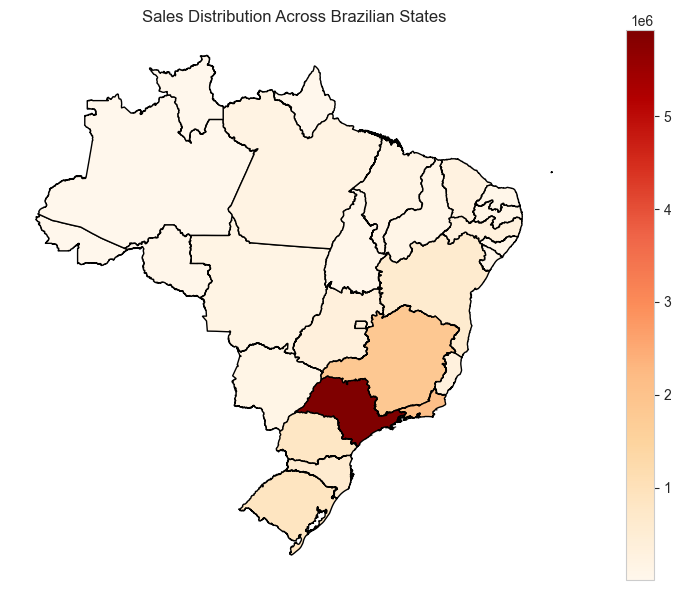

In [52]:
import geopandas as gpd
import matplotlib.pyplot as plt

# load brazil states map
brazil = gpd.read_file(
    "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
)

# aggregate revenue
state_sales = sales.groupby("customer_state")["total_price"].sum().reset_index()

# merge map with sales data
brazil_sales = brazil.merge(state_sales, left_on="sigla", right_on="customer_state")

# plot
brazil_sales.plot(
    column="total_price",
    cmap="OrRd",
    legend=True,
    edgecolor="black"
)

plt.title("Sales Distribution Across Brazilian States")
plt.axis("off")

plt.tight_layout()
plt.savefig("visualizations/geographic_sales_map.png", dpi=300, bbox_inches="tight")
plt.show()

#### Insight

The geographic distribution map further confirms that sales activity is
heavily concentrated in a few economically developed states.

States such as São Paulo and Rio de Janeiro represent major economic
centers and naturally generate a higher volume of e-commerce activity.

This concentration suggests that logistics infrastructure and delivery
networks may already be optimized for these regions, but it also
highlights opportunities for expanding market penetration in less
represented states.

### Top States by Order Volume

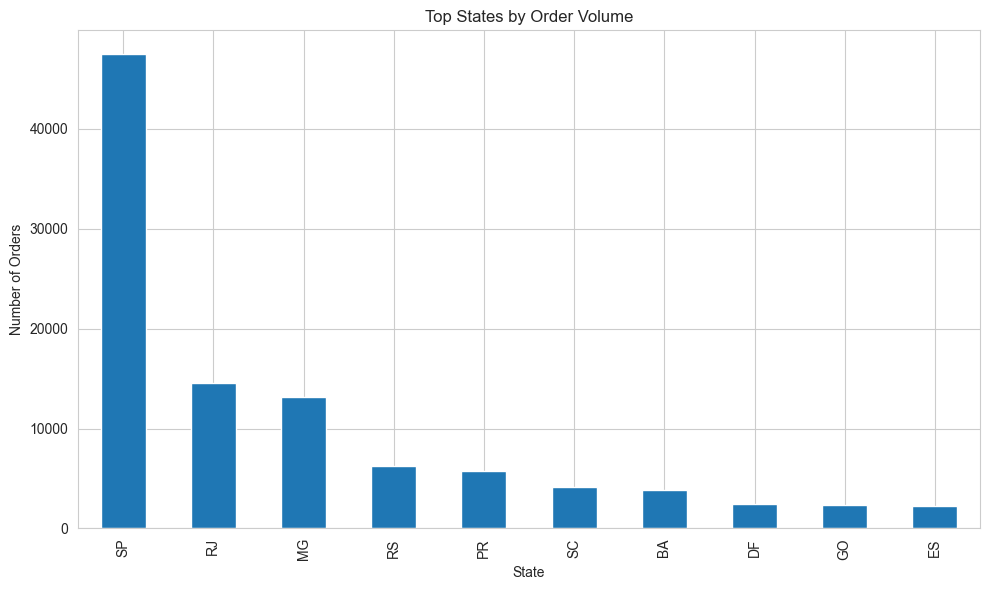

In [53]:
state_orders = sales["customer_state"].value_counts().head(10)

state_orders.plot(kind="bar")

plt.title("Top States by Order Volume")
plt.xlabel("State")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.savefig("visualizations/orders_by_state.png", dpi=300, bbox_inches="tight")
plt.show()

#### Insight

Customer demand is geographically concentrated in a few major Brazilian
states. Regions with higher population density and economic activity
generate significantly more orders than other areas.

This geographic clustering highlights potential opportunities for
regional logistics optimization, such as establishing fulfillment
centers closer to high-demand areas to reduce delivery times.

Understanding geographic demand patterns also allows companies to tailor
regional marketing strategies more effectively.

### Top Cities by Revenue

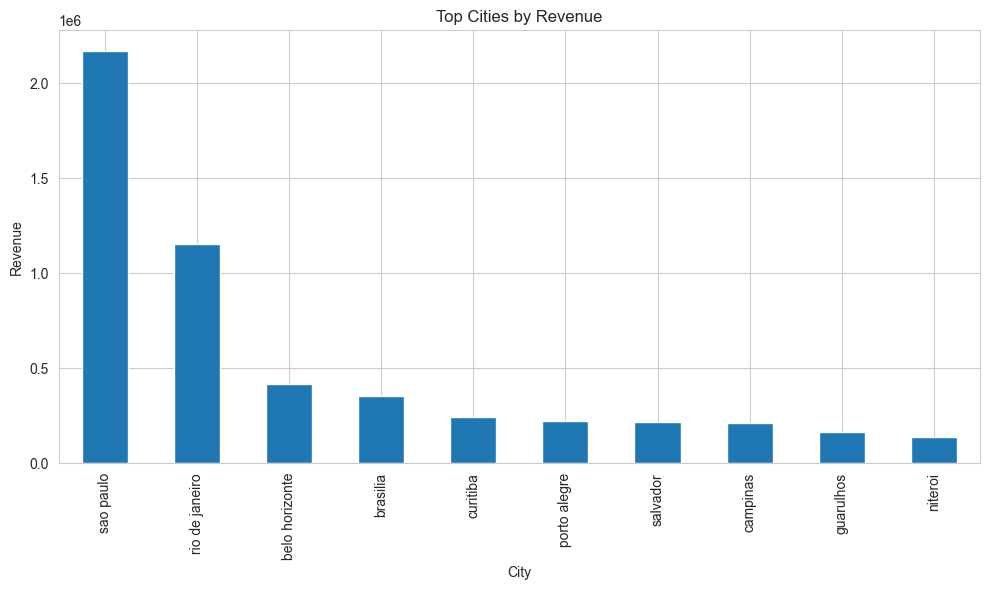

In [33]:
top_cities = sales.groupby("customer_city")["total_price"].sum().sort_values(ascending=False).head(10)

top_cities.plot(kind="bar")

plt.title("Top Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

#### Insight

Revenue concentration at the city level mirrors the broader geographic
pattern observed at the state level.

Large metropolitan areas dominate the top positions, reflecting the
strong relationship between urban population density and e-commerce
activity.

This insight suggests that city-level targeting could be an effective
strategy for localized marketing campaigns and last-mile delivery
optimization.

## Customer Segmentation Analysis

Customer segmentation helps identify different customer groups based on
purchasing behavior.

Using RFM metrics (Recency, Frequency, Monetary), we can better understand
which customers generate the most value and how often they engage with the
platform.

In [23]:
import datetime as dt

snapshot_date = sales["order_purchase_timestamp"].max() + dt.timedelta(days=1)

rfm = sales.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": lambda x: (snapshot_date - x.max()).days,
    "order_id": "count",
    "total_price": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19
0000f46a3911fa3c0805444483337064,542,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62
0004aac84e0df4da2b147fca70cf8255,293,1,196.89


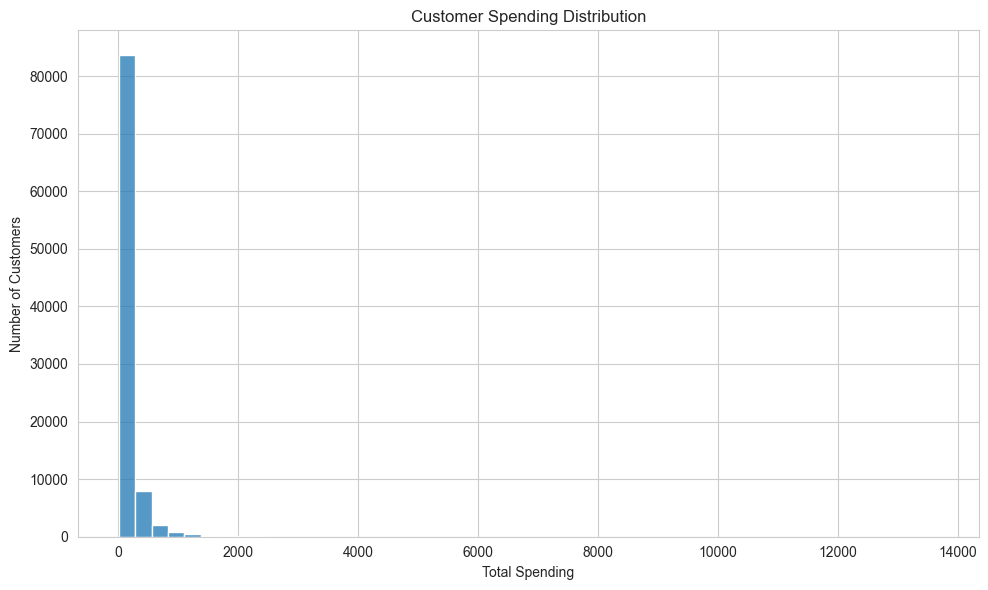

In [54]:
# visualize customer value distribution
sns.histplot(rfm["Monetary"], bins=50)

plt.title("Customer Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("visualizations/order_value_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

The distribution of customer spending indicates that most customers make
relatively small purchases, while a smaller group of customers generates
a large share of total revenue.

This pattern is common in e-commerce and suggests opportunities for
targeted marketing strategies aimed at retaining high-value customers.

### Average Order Value by Product Category

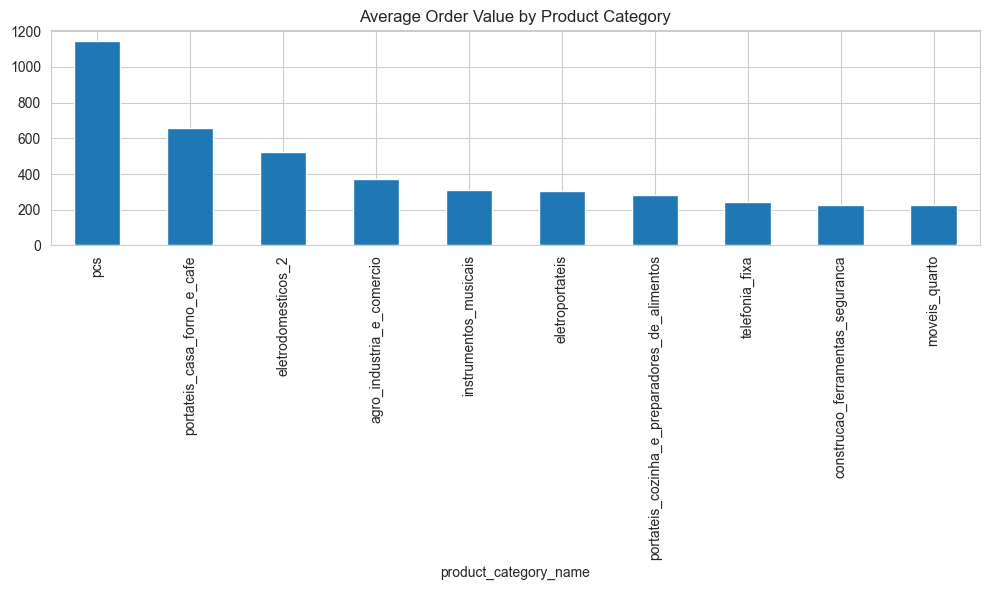

In [43]:
avg_category = sales.groupby("product_category_name")["total_price"].mean().sort_values(ascending=False).head(10)

avg_category.plot(kind="bar")

plt.title("Average Order Value by Product Category")
plt.tight_layout()
plt.show()

#### Insight

The average order value varies considerably across product categories,
indicating that some categories tend to involve higher-value purchases
than others.

Understanding which categories drive higher transaction values can help
businesses prioritize premium product segments and tailor pricing or
bundling strategies accordingly.

## Customer Retention Cohort Analysis

Customer retention is a key metric for e-commerce platforms. Understanding
how many customers return to make additional purchases helps evaluate
customer satisfaction and long-term engagement.

Cohort analysis groups customers by the month of their first purchase and
tracks how many of them return in subsequent months.

In [26]:
# convert to month
sales["order_month"] = sales["order_purchase_timestamp"].dt.to_period("M")

# first purchase month per customer
sales["cohort_month"] = sales.groupby("customer_unique_id")["order_purchase_timestamp"]\
    .transform("min").dt.to_period("M")

In [27]:
# calculate cohort index
sales["cohort_index"] = (
    (sales["order_month"].dt.year - sales["cohort_month"].dt.year) * 12
    + (sales["order_month"].dt.month - sales["cohort_month"].dt.month)
    + 1
)

In [28]:
# create cohort table
cohort_data = sales.groupby(["cohort_month", "cohort_index"])\
    ["customer_unique_id"].nunique().reset_index()

cohort_table = cohort_data.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="customer_unique_id"
)

In [30]:
# calculate retention rate
cohort_size = cohort_table.iloc[:,0]

retention_table = cohort_table.divide(cohort_size, axis=0)

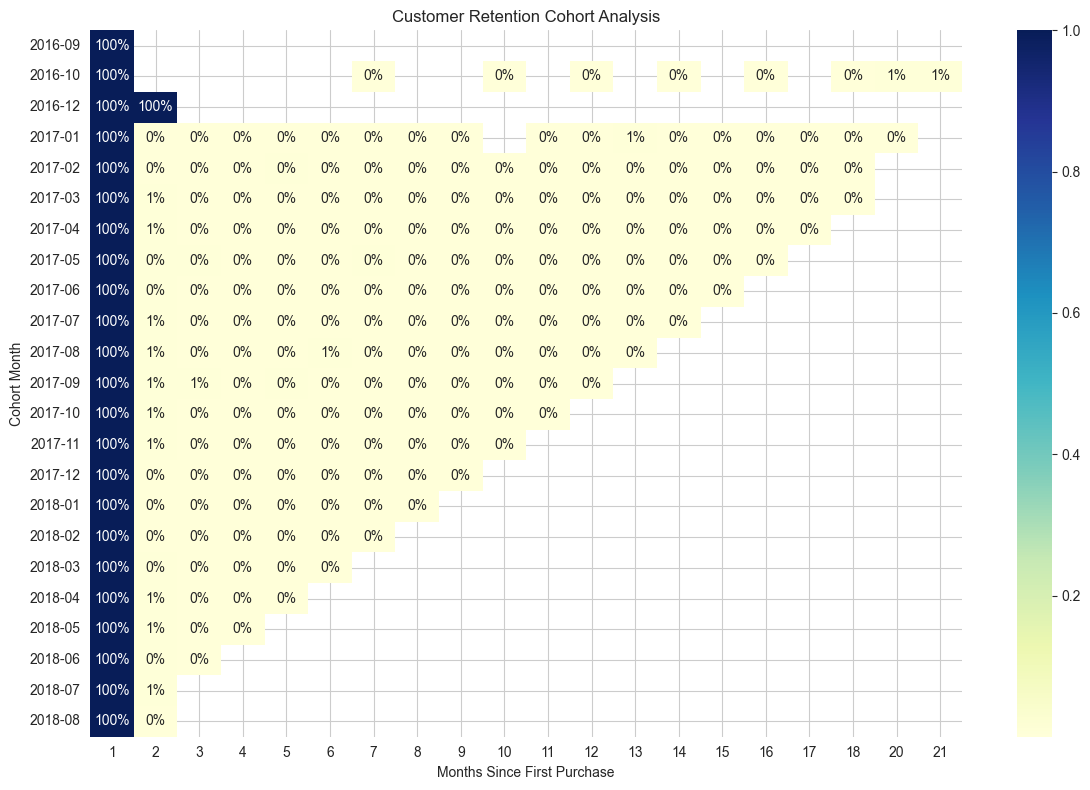

In [51]:
plt.figure(figsize=(12,8))

sns.heatmap(
    retention_table,
    annot=True,
    fmt=".0%",
    cmap="YlGnBu"
)

plt.title("Customer Retention Cohort Analysis")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.tight_layout()
plt.savefig("visualizations/cohort_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

#### Insight

The cohort heatmap reveals how customer retention changes over time.

Retention drops significantly after the first purchase month, suggesting
that many customers only make a single purchase. However, a smaller group
of customers continues to return in subsequent months.

This indicates an opportunity for loyalty programs, personalized marketing,
or targeted promotions aimed at encouraging repeat purchases.

## Correlation Analysis

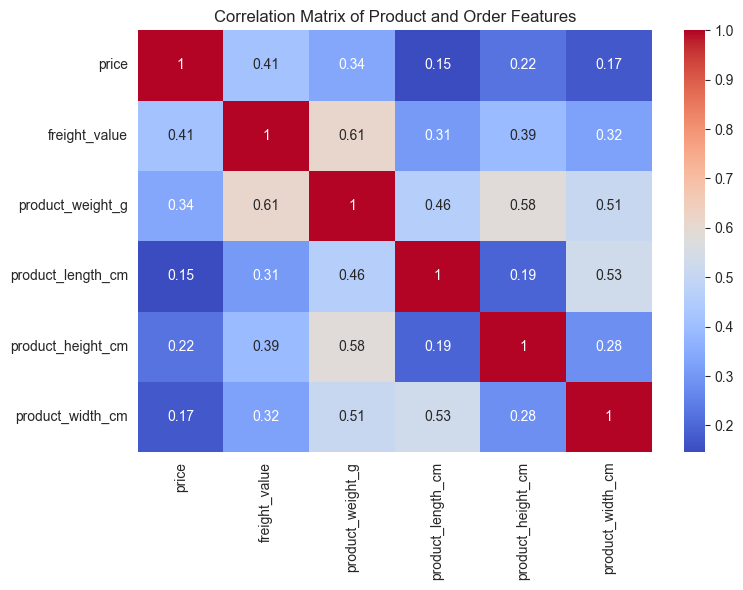

In [40]:
numeric_cols = [
    "price",
    "freight_value",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

corr_matrix = sales[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix of Product and Order Features")

plt.tight_layout()
plt.show()

#### Insight

The correlation matrix provides insight into relationships between
product attributes and order pricing.

Shipping cost shows a moderate relationship with product size and
weight, which is expected since larger or heavier products typically
incur higher logistics costs.

Understanding these relationships can help e-commerce platforms optimize
shipping strategies and pricing models.

## Key Insights

1. Sales demonstrate a consistent upward trend over time, indicating
growing adoption of the platform.

2. Revenue is concentrated in a limited number of product categories,
suggesting strong demand for specific product segments.

3. Customer demand is geographically concentrated in several major
Brazilian states and metropolitan areas.

4. Seasonal purchasing patterns show increased activity during the final
quarter of the year.

5. Customer retention analysis suggests that many customers make only a
single purchase, highlighting opportunities for improving repeat
engagement through loyalty programs or targeted promotions.

## Business Recommendations

• Increase marketing investment during high-demand seasonal periods to
maximize revenue during peak shopping months.

• Prioritize inventory management and supplier relationships for
top-performing product categories.

• Expand logistics infrastructure in high-demand regions to reduce
delivery times and improve customer satisfaction.

• Implement customer retention strategies such as loyalty programs,
personalized promotions, and targeted re-engagement campaigns to
encourage repeat purchases.

## Business Implications

The findings suggest that sales growth is driven by both seasonal demand
patterns and geographic concentration of customers.

Strategic investments in logistics, marketing, and product assortment could
further accelerate platform growth.

## Limitations

Several limitations should be considered when interpreting these results:

• The dataset represents historical transactions and may not reflect current
  market conditions.

• Some product metadata was missing and required imputation.

• External factors such as marketing campaigns or economic conditions are not
  captured in the dataset.

## Future Work

While this analysis provides valuable insights into sales trends and
customer behavior, additional analysis could further enhance the
understanding of the platform’s performance.

Potential future work includes:

• predictive modeling to forecast future sales trends
• advanced customer lifetime value estimation
• delivery time analysis using logistics data
• sentiment analysis of customer reviews

## Conclusion

This analysis provided insights into sales trends, customer behavior, and
regional demand patterns within the Olist e-commerce platform.

The findings highlight the importance of seasonal demand planning, geographic
logistics optimization, and strategic product management in driving
e-commerce growth.